In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('StressLevelDataset.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1100, 21)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [3]:
df = pd.read_csv('StressLevelDataset.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1100, 21)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [6]:
print("Column Names and Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Column Names and Data Types:
anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

Basic Statistics:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

Total missing values: 0


In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [9]:
expected_ranges = {
    'anxiety_level': (0, 21),
    'self_esteem': (0, 30),
    'mental_health_history': (0, 1),
    'depression': (0, 27),
    'headache': (0, 5),
    'blood_pressure': (1, 3),
    'sleep_quality': (0, 5),
    'breathing_problem': (0, 5),
    'noise_level': (0, 5),
    'living_conditions': (0, 5),
    'safety': (0, 5),
    'basic_needs': (0, 5),
    'academic_performance': (0, 5),
    'study_load': (0, 5),
    'teacher_student_relationship': (0, 5),
    'future_career_concerns': (0, 5),
    'social_support': (0, 3),
    'peer_pressure': (0, 5),
    'extracurricular_activities': (0, 5),
    'bullying': (0, 5),
    'stress_level': (0, 2)
}

print("Checking for out-of-range values:")
found_issues = False
for col, (low, high) in expected_ranges.items():
    out = df[(df[col] < low) | (df[col] > high)]
    if len(out) > 0:
        print(f"  {col}: {len(out)} out-of-range values")
        found_issues = True

if not found_issues:
    print("  All columns are within expected ranges — no inconsistencies found.")

Checking for out-of-range values:
  All columns are within expected ranges — no inconsistencies found.


In [ ]:
continuous_features = ['anxiety_level', 'self_esteem', 'depression']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, continuous_features):
    ax.boxplot(df[col])
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel('Value')
plt.suptitle('Outlier Detection – Continuous Features', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
print("Outliers retained — they represent valid extreme responses from students.")
df_clean = df.copy()
print(f"Clean dataset shape after Stage 1: {df_clean.shape}")


Outliers retained — they represent valid extreme responses from students.
Clean dataset shape after Stage 1: (1100, 21)


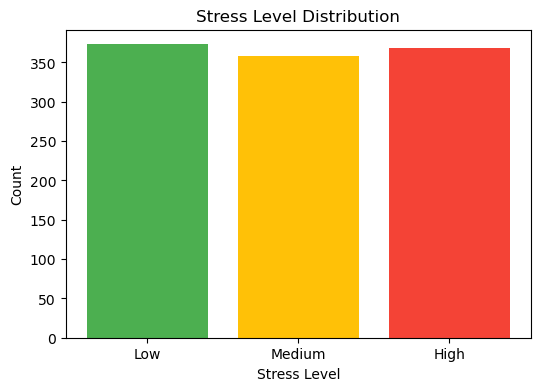

Stress Level Distribution:
  Low (0): 373 students (33.9%)
  Medium (1): 358 students (32.5%)
  High (2): 369 students (33.5%)


In [11]:
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
counts = df_clean['stress_level'].value_counts().sort_index()
labels = [label_map[i] for i in counts.index]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

print("Stress Level Distribution:")
for k, v in label_map.items():
    print(f"  {v} ({k}): {counts[k]} students ({counts[k]/len(df_clean)*100:.1f}%)")

In [12]:
X = df_clean.drop('stress_level', axis=1)
y = df_clean['stress_level']

standard_cols = ['anxiety_level', 'self_esteem', 'depression']

X_scaled = X.copy()
scaler_std = StandardScaler()
X_scaled[standard_cols] = scaler_std.fit_transform(X[standard_cols])

print("StandardScaler applied to:", standard_cols)
X_scaled[standard_cols].describe()

StandardScaler applied to: ['anxiety_level', 'self_esteem', 'depression']


,anxiety_level,self_esteem,depression
count,1.100000e+03,1.100000e+03,1.100000e+03
mean,-1.356491e-16,-3.229740e-18,8.074349e-17
std,1.000455e+00,1.000455e+00,1.000455e+00
min,-1.809328e+00,-1.988391e+00,-1.625618e+00
25%,-8.280983e-01,-7.580391e-01,-8.487679e-01
50%,-1.040698e-02,1.367622e-01,-7.191751e-02
75%,8.072843e-01,9.197134e-01,8.344079e-01
max,1.624976e+00,1.367114e+00,1.870208e+00


In [13]:
minmax_cols = ['headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
               'noise_level', 'living_conditions', 'safety', 'basic_needs',
               'academic_performance', 'study_load', 'teacher_student_relationship',
               'future_career_concerns', 'social_support', 'peer_pressure',
               'extracurricular_activities', 'bullying']

scaler_mm = MinMaxScaler()
X_scaled[minmax_cols] = scaler_mm.fit_transform(X[minmax_cols])

print("MinMaxScaler applied to:", len(minmax_cols), "columns")
X_scaled[minmax_cols].describe()

MinMaxScaler applied to: 16 columns


,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,0.501636,0.590909,0.532000,0.550727,0.529818,0.503636,0.547455,0.554545,0.554545,0.524364,0.529636,0.529818,0.627273,0.546909,0.553455,0.523455
std,0.281871,0.416787,0.309677,0.280143,0.265625,0.223842,0.281234,0.286752,0.282919,0.263156,0.276916,0.305875,0.349275,0.285053,0.283512,0.306192
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.000000,0.200000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.200000,0.333333,0.400000,0.400000,0.200000
50%,0.600000,0.500000,0.500000,0.600000,0.600000,0.400000,0.400000,0.600000,0.400000,0.400000,0.400000,0.400000,0.666667,0.400000,0.500000,0.600000
75%,0.600000,1.000000,0.800000,0.800000,0.600000,0.600000,0.800000,0.800000,0.800000,0.600000,0.800000,0.800000,1.000000,0.800000,0.800000,0.800000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
print("Data types after transformation:")
print(X_scaled.dtypes)
print("\nAll features are numeric — no additional encoding needed.")
print("Target (stress_level) is ordinal: 0=Low, 1=Medium, 2=High")

Data types after transformation:
anxiety_level                   float64
self_esteem                     float64
mental_health_history             int64
depression                      float64
headache                        float64
blood_pressure                  float64
sleep_quality                   float64
breathing_problem               float64
noise_level                     float64
living_conditions               float64
safety                          float64
basic_needs                     float64
academic_performance            float64
study_load                      float64
teacher_student_relationship    float64
future_career_concerns          float64
social_support                  float64
peer_pressure                   float64
extracurricular_activities      float64
bullying                        float64
dtype: object

All features are numeric — no additional encoding needed.
Target (stress_level) is ordinal: 0=Low, 1=Medium, 2=High


In [15]:
X_engineered = X_scaled.copy()

# Physical Symptoms Score: combines headache, breathing problems, poor sleep
X_engineered['physical_symptoms_score'] = (
    X_scaled['headache'] + X_scaled['breathing_problem'] + (1 - X_scaled['sleep_quality'])
) / 3

# Academic Pressure Score: combines study load, low academic performance, career worries
X_engineered['academic_pressure_score'] = (
    X_scaled['study_load'] + (1 - X_scaled['academic_performance']) + X_scaled['future_career_concerns']
) / 3

# Social Environment Score: combines peer pressure, bullying, lack of social support
X_engineered['social_environment_score'] = (
    X_scaled['peer_pressure'] + X_scaled['bullying'] + (1 - X_scaled['social_support'])
) / 3

print("New engineered features added:")
print("  physical_symptoms_score")
print("  academic_pressure_score")
print("  social_environment_score")
print(f"\nNew dataset shape: {X_engineered.shape}")
X_engineered[['physical_symptoms_score','academic_pressure_score','social_environment_score']].describe()

New engineered features added:
  physical_symptoms_score
  academic_pressure_score
  social_environment_score

New dataset shape: (1100, 23)


,physical_symptoms_score,academic_pressure_score,social_environment_score
count,1100.000000,1100.000000,1100.000000
mean,0.506788,0.499879,0.481030
std,0.243185,0.241411,0.264847
min,0.066667,0.000000,0.133333
25%,0.266667,0.266667,0.200000
50%,0.533333,0.466667,0.444444
75%,0.733333,0.733333,0.755556
max,0.933333,1.000000,1.000000


In [16]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_engineered, y)

feature_scores = pd.DataFrame({
    'Feature': X_engineered.columns,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("Feature Importance Scores (ANOVA F-test):")
print(feature_scores.to_string(index=False))

Feature Importance Scores (ANOVA F-test):
                     Feature     F_Score       P_Value
    social_environment_score 1202.149010 3.496922e-277
     academic_pressure_score 1175.635223 1.510119e-273
              blood_pressure 1106.223910 9.277323e-264
     physical_symptoms_score 1087.705509 4.449606e-261
                 self_esteem  775.386130 1.268559e-210
                    bullying  712.871269 4.227007e-199
               sleep_quality  710.124696 1.397301e-198
      future_career_concerns  684.270952 1.228543e-193
               anxiety_level  655.453225 5.296746e-188
                  depression  652.629287 1.920442e-187
        academic_performance  639.222921 9.060029e-185
                      safety  613.634750 1.397009e-179
                 basic_needs  600.120070 8.543327e-177
                    headache  570.226316 1.634364e-170
  extracurricular_activities  549.800151 4.007655e-166
               peer_pressure  539.338954 7.633016e-164
teacher_student_relatio

In [17]:
top_10_features = feature_scores.head(10)['Feature'].tolist()
print("Top 10 features selected for modelling:")
for i, f in enumerate(top_10_features, 1):
    print(f"  {i}. {f}")

X_selected = X_engineered[top_10_features]
print(f"\nShape after feature selection: {X_selected.shape}")

Top 10 features selected for modelling:
  1. social_environment_score
  2. academic_pressure_score
  3. blood_pressure
  4. physical_symptoms_score
  5. self_esteem
  6. bullying
  7. sleep_quality
  8. future_career_concerns
  9. anxiety_level
  10. depression

Shape after feature selection: (1100, 10)


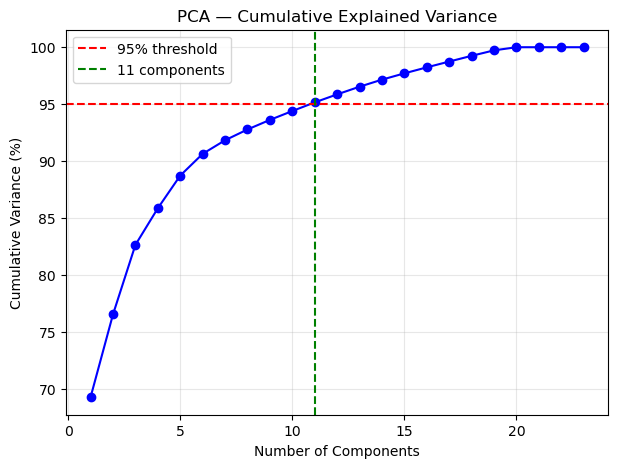

Components needed to retain 95% variance: 11
Original features: 23 → Reduced to: 11 components


In [18]:
pca = PCA()
pca.fit(X_engineered)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 'bo-')
plt.axhline(y=95, color='red', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Components needed to retain 95% variance: {n_components_95}")
print(f"Original features: {X_engineered.shape[1]} → Reduced to: {n_components_95} components")

In [19]:
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_engineered)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)

print(f"PCA reduced dataset shape: {X_pca_df.shape}")
print(f"Variance retained: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
X_pca_df.head()

PCA reduced dataset shape: (1100, 11)
Variance retained: 95.15%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-0.156916,0.651209,-0.203716,-0.149392,-0.481167,-0.437004,-0.025556,0.138710,0.032041,-0.012869,0.081035
1,1.818813,-0.274607,-0.492950,-0.049247,0.524289,-0.223682,0.193800,-0.080633,-0.236441,0.216469,0.171296
2,0.145521,0.316402,0.112925,-0.601370,0.027524,0.347881,-0.287330,-0.156173,0.018657,-0.023084,-0.038520
3,1.538317,0.094732,-0.341051,0.181736,0.485911,-0.030850,0.108064,-0.131939,0.025955,0.053814,-0.026634
4,-0.593355,1.095097,-0.349210,1.260641,0.238367,-0.151304,-0.089354,-0.333329,0.331216,-0.259264,-0.280444
